In [1]:
# 환경 설정 및 기본 라이브러리
from dotenv import load_dotenv
from langchain_teddynote import logging
import json
import os
from typing import List, Literal, Annotated
from typing_extensions import TypedDict

# 환경 변수 로드
load_dotenv()
logging.langsmith("LangGraph")

# 디버깅 로그 제어 설정
DEBUG_MODE = False  # True로 설정하면 디버깅 로그 출력, False면 출력 안함

def debug_print(*args, **kwargs):
    """디버깅 로그를 조건부로 출력하는 함수"""
    if DEBUG_MODE:
        print(*args, **kwargs)

globals()['DEBUG_MODE'] = DEBUG_MODE
globals()['debug_print'] = debug_print

print("✅ 환경 설정 완료")


LangSmith 추적을 시작합니다.
[프로젝트명]
LangGraph
✅ 환경 설정 완료


In [2]:
# LangChain 및 AI 모델 관련 라이브러리
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.documents import Document
from langchain_core.runnables import RunnableConfig
from langchain_openai import ChatOpenAI
from langchain_teddynote.models import get_model_name, LLMs
from langchain_teddynote.tools.tavily import TavilySearch
from langchain_teddynote.messages import stream_graph, random_uuid
from langchain import hub
from langchain.retrievers.document_compressors import CohereRerank
from pydantic import BaseModel, Field

# LangGraph 관련 라이브러리
from langgraph.graph import END, StateGraph, START
from langgraph.checkpoint.memory import MemorySaver

# 최신 LLM 모델 이름 가져오기
MODEL_NAME = get_model_name(LLMs.GPT4)

print("✅ LangChain 및 AI 모델 라이브러리 로드 완료")


✅ LangChain 및 AI 모델 라이브러리 로드 완료


In [3]:
# 경작지 위치 관리 기능
from gps_class import GeocodingManager

# 사용자 경작지 정보를 저장할 전역 변수
USER_FARM_INFO = None

# 지오코딩 매니저 인스턴스 생성
try:
    geo_manager = GeocodingManager()
    print("✅ GeocodingManager 인스턴스 생성 완료")
except Exception as e:
    print(f"❌ GeocodingManager 초기화 실패: {e}")
    geo_manager = None

def get_farm_location():
    """현재 설정된 경작지 위치 정보를 반환하는 함수"""
    global USER_FARM_INFO
    return USER_FARM_INFO

def get_farm_info():
    """현재 설정된 경작지 정보를 반환하는 함수"""
    global USER_FARM_INFO
    if USER_FARM_INFO is None:
        print("⚠️ 경작지 정보가 설정되지 않았습니다.")
    return USER_FARM_INFO

def set_farm_info(farm_data):
    """경작지 정보를 직접 설정하는 함수"""
    global USER_FARM_INFO
    USER_FARM_INFO = farm_data
    print(f"✅ 경작지 정보가 설정되었습니다: {farm_data.get('road_address', 'N/A')}")

def clear_farm_info():
    """경작지 정보를 초기화하는 함수"""
    global USER_FARM_INFO
    USER_FARM_INFO = None
    print("✅ 경작지 정보가 초기화되었습니다.")

def get_location_context():
    """현재 경작지 위치 정보를 AI 모델에서 사용할 수 있는 구조화된 텍스트로 변환"""
    farm_info = get_farm_info()
    
    if not farm_info:
        return "경작지 위치 정보가 설정되지 않았습니다."
    
    context = f"""
📍 경작지 위치 정보:
- 주소: {farm_info.get('road_address', 'N/A')}
- 법정동: {farm_info.get('legal_address', 'N/A')}
- 좌표: ({farm_info.get('longitude')}, {farm_info.get('latitude')})
"""
    return context.strip()

print("✅ 경작지 위치 관리 모듈이 로드되었습니다.")


✅ GeocodingManager 클래스가 정의되었습니다.
✅ GeocodingManager 인스턴스 생성 완료
✅ 경작지 위치 관리 모듈이 로드되었습니다.


In [4]:
def setup_farm_location():
    """사용자가 직접 주소를 입력하여 경작지 위치를 설정하는 함수"""
    global USER_FARM_INFO
    
    if not geo_manager:
        print("❌ 지오코딩 매니저가 초기화되지 않았습니다.")
        return None
    
    print("🌱 경작지 위치 설정")
    print("=" * 50)
    
    while True:
        try:
            print("\n📍 경작지 주소를 입력해주세요:")
            print("예시: 서울시 강남구 테헤란로 123, 전라남도 순천시 중앙로 255")
            print("      또는: 순천대학교, 서울시청, 강남역 등")
            
            user_address = input("\n주소: ").strip()
            
            if not user_address:
                print("❌ 주소를 입력해주세요.")
                continue
            
            print(f"\n🔍 입력된 주소: {user_address}")
            print("📍 주소를 좌표로 변환하고 정확한 주소를 확인하는 중...")
            
            # 지오코딩 + 리버스 지오코딩 통합 처리
            result = geo_manager.get_final_address(user_address, verbose=False)
            
            if result:
                print("\n✅ 주소 변환 완료!")
                print("=" * 50)
                print("📋 확인된 정보:")
                print(f"   입력 주소: {result['input_address']}")
                print(f"   좌표: {result['coordinates']['longitude']}, {result['coordinates']['latitude']}")
                print(f"   도로명 주소: {result['final_address']['road_address']}")
                print(f"   법정동 주소: {result['final_address']['legal_address']}")
                print("=" * 50)
                
                # 사용자 확인
                confirm = input("\n이 위치가 맞나요? (y/n): ").lower().strip()
                if confirm in ['y', 'yes', '예', 'ㅇ']:
                    USER_FARM_INFO = {
                        'longitude': result['coordinates']['longitude'],
                        'latitude': result['coordinates']['latitude'],
                        'road_address': result['final_address']['road_address'],
                        'legal_address': result['final_address']['legal_address'],
                        'full_address': result['final_address']['full_address'],
                        'user_input': user_address,
                        'raw_data': result
                    }
                    
                    print("\n🎉 경작지 위치 설정 완료!")
                    print(f"📍 설정된 위치: {USER_FARM_INFO['road_address']}")
                    print(f"📍 좌표: {USER_FARM_INFO['longitude']}, {USER_FARM_INFO['latitude']}")
                    
                    return USER_FARM_INFO
                else:
                    print("다시 입력해주세요.")
                    continue
            else:
                print("❌ 주소를 찾을 수 없습니다. 다시 시도해주세요.")
                continue
                
        except KeyboardInterrupt:
            print("\n\n❌ 사용자가 취소했습니다.")
            break
        except Exception as e:
            print(f"❌ 오류 발생: {e}")
            retry = input("다시 시도하시겠습니까? (y/n): ").lower().strip()
            if retry not in ['y', 'yes', '예', 'ㅇ']:
                break
    
    return None

print("✅ setup_farm_location() 함수가 정의되었습니다.")


✅ setup_farm_location() 함수가 정의되었습니다.


In [5]:
# RAG 시스템 초기화
from rag.pdf import PDFRetrievalChain

# 농작물 데이터 경로 설정
all_data_path = [
    {"path": "data/tomato/토마토 백과사전.pdf", "crop": "tomato"},
    {"path": "data/tomato/토마토 병해충 및 비료.pdf", "crop": "tomato"},
    {"path": "data/tomato/토마토 재배법.pdf", "crop": "tomato"},
    {"path": "data/tomato/토마토 농작업일정.pdf", "crop": "tomato"},
    {"path": "data/strawberry/딸기 병해충 및 비료.pdf", "crop": "strawberry"},
    {"path": "data/strawberry/딸기 재배법.pdf", "crop": "strawberry"},
    {"path": "data/strawberry/딸기 농작업일정.pdf", "crop": "strawberry"}
]

# 통합 RAG 체인 생성
combined_data = PDFRetrievalChain(
    all_data_path, 
    persist_dir="db/crop_vector", 
    force_rebuild=False
).create_chain()

combined_retriever = combined_data.retriever
combined_chain = combined_data.chain

print("✅ RAG 시스템 초기화 완료")


c:\Users\user\Documents\langchain-kr\Langraph1\rag\pdf.py:105: LangChainDeprecationWarning: The class `OpenAIEmbeddings` was deprecated in LangChain 0.0.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import OpenAIEmbeddings``.
  embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")


🔁 기존 벡터 DB 로드 중: db/crop_vector


c:\Users\user\Documents\langchain-kr\Langraph1\rag\pdf.py:109: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  vectorstore = Chroma(


✅ RAG 시스템 초기화 완료


In [6]:
# RAG 체인 및 프롬프트 설정
prompt = hub.pull("teddynote/rag-prompt")
llm = ChatOpenAI(model_name=MODEL_NAME, temperature=0)

# 문서 포맷팅 함수
def format_docs(docs):
    return "\n\n".join(
        [
            f'<document><content>{doc.page_content}</content><source>{doc.metadata["source"]}</source><page>{doc.metadata["page"]+1}</page></document>'
            for doc in docs
        ]
    )

# RAG 체인 생성
rag_chain = prompt | llm | StrOutputParser()

print("✅ RAG 체인 및 프롬프트 설정 완료")


✅ RAG 체인 및 프롬프트 설정 완료


In [7]:
# 웹 검색 도구 및 리랭커 설정
web_search_tool = TavilySearch(max_results=3)

reranker = CohereRerank(
    cohere_api_key=os.getenv("COHERE_API_KEY"),
    top_n=5,
    model="rerank-multilingual-v3.0"  # 한국어 지원 모델
)

print("✅ 웹 검색 도구 및 리랭커 설정 완료")


C:\Users\user\AppData\Local\Temp\ipykernel_22380\3581727996.py:4: LangChainDeprecationWarning: The class `CohereRerank` was deprecated in LangChain 0.0.30 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-cohere package and should be used instead. To use it run `pip install -U :class:`~langchain-cohere` and import as `from :class:`~langchain_cohere import CohereRerank``.
  reranker = CohereRerank(


✅ 웹 검색 도구 및 리랭커 설정 완료


In [8]:
# 질문 라우팅 모델
class RouteQuery(BaseModel):
    """사용자 쿼리를 가장 관련성 높은 데이터 소스로 라우팅하는 데이터 모델"""
    datasource: Literal["vectorstore", "web_search"] = Field(
        ...,
        description="Given a user question choose to route it to web search or a vectorstore.",
    )

# 질문 유효성 검사 모델
class QuestionValidity(BaseModel):
    """질문 유효성 검사를 위한 데이터 모델"""
    binary_score: str = Field(
        description="Is this question based on valid, known, or verifiable concepts? Answer 'yes' or 'no'"
    )

# 문서 관련성 평가 모델
class GradeDocuments(BaseModel):
    """검색된 문서의 질문 관련성을 평가하는 데이터 모델"""
    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

# 웹 문서 관련성 평가 모델
class GradewebDocuments(BaseModel):
    """웹 검색 문서의 관련성을 평가하는 데이터 모델"""
    binary_score: str = Field(
        description="Web search document is directly relevant to the question. Answer 'yes' or 'no'."
    )

# 할루시네이션 평가 모델
class GradeHallucinations(BaseModel):
    """생성된 답변의 할루시네이션 여부를 평가하는 데이터 모델"""
    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )

# 답변 품질 평가 모델
class GradeAnswer(BaseModel):
    """생성된 답변의 품질을 평가하는 데이터 모델"""
    binary_score: str = Field(
        description="Indicate 'yes' or 'no' whether the answer solves the question"
    )

# 질문 복잡도 평가 모델
class QuestionComplexity(BaseModel):
    """질문의 복잡도를 평가하는 모델"""
    complexity_level: str = Field(
        description="질문의 복잡도 수준: 'simple', 'multi_question', 'complex'"
    )
    question_type: str = Field(
        description="질문 유형: 'single', 'multiple', 'high_difficulty'"
    )
    needs_decomposition: bool = Field(
        description="질문 분해가 필요한지 여부"
    )

# 다중질의 분리 결과 모델
class MultiQuestionResult(BaseModel):
    """다중질의 분리 결과"""
    primary_question: str = Field(description="첫 번째 우선 질문")
    secondary_question: str = Field(description="두 번째 질문")
    question_count: int = Field(description="총 질문 개수")
    should_process_secondary: bool = Field(description="두 번째 질문도 처리할지 여부")

print("✅ AI 모델 및 평가 시스템 데이터 모델 정의 완료")


✅ AI 모델 및 평가 시스템 데이터 모델 정의 완료


In [9]:
# 질문 라우팅 시스템
llm = ChatOpenAI(model=MODEL_NAME, temperature=0)
structured_llm_router = llm.with_structured_output(RouteQuery)

# 라우팅 프롬프트
system = """당신은 농업 질문을 적절한 데이터 소스로 라우팅하는 전문가입니다.

## 라우팅 기준

### 벡터스토어 (crop_vector) 선택
- **지원되는 작물**: 토마토, 딸기만 지원
- **구체적인 질문**: 토마토나 딸기에 대한 재배법, 병해충, 농약 등

### 웹 검색 (web_search) 선택
- **지원되지 않는 작물**: 참외, 수박, 멜론, 고추, 상추 등
- **최신 정보 필요**: 최신 농업 기술, 시장 정보
- **일반적인 정보**: 농업과 관련 없는 질문

## 예시
- "토마토 재배법" → crop_vector
- "딸기 병해충 방제법" → crop_vector
- "참외 재배법" → web_search (지원되지 않는 작물)
- "수박 재배법" → web_search (지원되지 않는 작물)
- "최신 농업 기술" → web_search (최신 정보)

## 출력 형식
"crop_vector" 또는 "web_search"로만 응답하세요.
"""

route_prompt = ChatPromptTemplate.from_messages([
    ("system", system),
    ("human", "{question}"),
])

question_router = route_prompt | structured_llm_router

print("✅ 질문 라우팅 시스템 설정 완료")


✅ 질문 라우팅 시스템 설정 완료


In [10]:
# 질문 유효성 검사 시스템
structured_validator = llm.with_structured_output(QuestionValidity)

validation_prompt = ChatPromptTemplate.from_messages([
    ("system", """
당신은 농업 분야 전문가이자 전문 질문 재작성자입니다.  
벡터 데이터베이스 및 웹 검색에서 더 정확하고 유의미한 결과를 얻기 위해, 사용자로부터 받은 농업 관련 질문을 다음과 같이 처리합니다.

---

## 질문 유효성 평가 기준

### ✅ 유효한 질문 (yes)
1. **실제 존재하는 작물**: 토마토, 딸기, 고추, 옥수수, 참외, 수박, 멜론, 상추 등
2. **실제 존재하는 병해충**: 탄저병, 흰가루병, 노균병, 진딧물, 응애 등
3. **실제 존재하는 농약**: 살균제, 살충제, 제초제 등
4. **농업 관련 주제**: 재배법, 방제법, 환경조건, 수확시기 등
5. **다중 질문**: 여러 개의 유효한 질문이 하나로 묶인 경우

### ❌ 무효한 질문 (no)
1. **존재하지 않는 개념**: "우주고추", "마법농약" 등
2. **논리적 모순**: "겨울철 수박 재배" (기후상 불가능)
3. **농업과 무관**: "자동차 정비법", "요리 레시피" 등
4. **의미 없는 표현**: "농사가 좋아요", "작물이 예뻐요" 등

## 질문 재작성 원칙
- 각 질문을 명확하고 구체적으로 분리
- 농업 전문 용어 사용
- 검색 최적화 키워드 포함

## 예시
입력: "고추 탄저병에 쓰이는 농약과 옥수수 재배법"
출력: 
고추 탄저병 방제용 농약 종류와 사용법 → yes
옥수수 재배 방법과 관리 기술 → yes

입력: "우주고추 재배법"
출력: 우주고추 재배법 → no: 우주고추는 존재하지 않는 작물입니다.

입력: "겨울철 수박 재배법"
출력: 겨울철 수박 재배법 → no: 겨울철 수박 재배는 기후상 불가능합니다.

## 출력 형식
각 질문별로 "yes" 또는 "no: 이유"와 함께 재작성된 질문을 한 줄씩 작성하세요.
"""),
    ("human", "다음 질문이 개념적으로 타당한가요?\n\n{question}")
])

question_validator = validation_prompt | structured_validator

print("✅ 질문 유효성 검사 시스템 설정 완료")


✅ 질문 유효성 검사 시스템 설정 완료


In [11]:
# 문서 관련성 평가 시스템
structured_llm_grader = llm.with_structured_output(GradeDocuments)

grade_system = """
당신은 검색된 문서가 질문과 관련있는지 평가하는 전문가입니다.

## 평가 기준

### ✅ 관련 있음 (yes)
1. **작물 일치**
   - 질문의 작물과 문서의 작물이 일치
   - 예: 질문이 "고추" → 문서도 "고추" 관련

2. **주제 일치**
   - 질문의 주제와 문서의 주제가 일치
   - 예: 질문이 "방제법" → 문서도 "방제법" 관련

3. **정보 포함**
   - 문서가 질문에 답변할 수 있는 정보 포함

### ❌ 관련 없음 (no)
1. **작물 불일치**
   - 질문의 작물과 문서의 작물이 다름
   - 예: 질문이 "고추" → 문서는 "토마토"

2. **주제 불일치**
   - 질문의 주제와 문서의 주제가 다름
   - 예: 질문이 "방제법" → 문서는 "재배법"

3. **정보 부족**
   - 문서가 질문에 답변할 수 있는 정보가 부족

## 출력 형식
"yes" 또는 "no"로만 응답하세요.

## 예시
- 질문: "고추 탄저병 방제법"
- 문서: "고추 탄저병 방제에 대한 상세한 정보..." → yes
- 문서: "토마토 재배법에 대한 정보..." → no
- 문서: "고추 재배 환경에 대한 정보..." → no
"""

grade_prompt = ChatPromptTemplate.from_messages([
    ("system", grade_system),
    ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
])

retrieval_grader = grade_prompt | structured_llm_grader

print("✅ 문서 관련성 평가 시스템 설정 완료")


✅ 문서 관련성 평가 시스템 설정 완료


In [12]:
# 웹 검색 문서 관련성 평가 시스템
structured_web_grader = llm.with_structured_output(GradewebDocuments)

web_system_prompt = """
당신은 웹 검색 결과의 관련성을 평가하는 전문가입니다.

## 평가 기준 (관대한 버전)

### ✅ 관련 있음 (yes) - 다음 중 하나라도 해당하면
1. **직접적 관련**: 질문과 직접적으로 관련된 내용
2. **농업 관련성**: 농업, 재배, 작물과 관련된 내용
3. **일반적 관련성**: 과일, 채소, 농작물과 관련된 내용
4. **유사 주제**: 재배법, 농업 기술, 원예 등
5. **부분적 관련**: 질문의 일부 키워드와 관련된 내용

### ❌ 관련 없음 (no) - 다음에만 해당하는 경우
1. **완전히 다른 주제**: 자동차, 의학, 기술 등 농업과 전혀 관련 없음
2. **순수 홍보**: 특정 제품만 홍보하는 내용
3. **의미 없는 내용**: 농업과 전혀 관련 없는 정보

## 예시
- 질문: "참외 재배법"
- 문서: "참외 재배에 대한 상세한 가이드..." → yes
- 문서: "과일 재배의 일반적인 방법..." → yes
- 문서: "참외 요리법" → yes (참외 관련)
- 문서: "멜론 재배법" → yes (유사 작물)
- 문서: "농작물 재배 팁" → yes (농업 관련)
- 문서: "자동차 정비법" → no (완전히 다른 주제)

## 주의사항
- 가능한 한 관대하게 평가하세요
- 농업과 관련된 내용은 대부분 'yes'로 판정
- 확실히 관련 없는 경우에만 'no'로 판정
"""

web_grade_prompt = ChatPromptTemplate.from_messages([
    ("system", web_system_prompt),
    ("human", "Web document: \n\n {document} \n\n User question: {question}"),
])

web_retrieval_grader = web_grade_prompt | structured_web_grader

print("✅ 웹 검색 문서 관련성 평가 시스템 설정 완료")


✅ 웹 검색 문서 관련성 평가 시스템 설정 완료


In [13]:
# 할루시네이션 및 답변 품질 평가 시스템
structured_llm_grader = llm.with_structured_output(GradeHallucinations)

hallucination_system = """
당신은 생성된 답변의 할루시네이션(환각) 여부를 평가하는 전문가입니다.

## 평가 기준

### ✅ 문서에 근거함 (yes)
1. **명시적 언급**
   - 답변의 모든 핵심 정보가 문서에 명시적으로 언급됨
   - 구체적인 수치, 방법, 절차가 문서에 포함됨

2. **논리적 추론**
   - 문서의 정보를 바탕으로 한 합리적인 추론
   - 문서 내용의 자연스러운 확장

3. **정보의 일치성**
   - 답변의 정보가 문서 내용과 일치
   - 모순되는 정보가 없음

### ❌ 할루시네이션 (no)
1. **문서에 없는 정보**
   - 문서에 언급되지 않은 구체적인 정보 추가
   - 문서 범위를 벗어나는 상세한 설명

2. **과도한 일반화**
   - 문서의 제한된 정보를 과도하게 일반화
   - 문서에서 확인할 수 없는 광범위한 주장

3. **정보의 왜곡**
   - 문서 내용을 잘못 해석하거나 왜곡
   - 문서에 없는 인과관계 주장

4. **모순되는 정보**
   - 문서 내용과 모순되는 정보 포함
   - 문서에서 확인할 수 없는 반대 주장

## 평가 방법
1. 답변의 각 주요 주장을 문서와 대조
2. 구체적인 정보(수치, 방법, 절차)의 출처 확인
3. 논리적 추론의 타당성 검증

## 출력 형식
"yes" (문서에 근거함) 또는 "no" (할루시네이션)로만 응답하세요.

## 예시
- 질문: "고추 탄저병 방제법"
- 문서: "고추 탄저병은 살균제로 방제할 수 있습니다."
- 답변: "고추 탄저병은 살균제로 방제할 수 있습니다." → yes
- 답변: "고추 탄저병은 살균제 A와 B를 1:1 비율로 혼합하여 7일 간격으로 3회 살포해야 합니다." → no (구체적 정보가 문서에 없음)
"""

hallucination_prompt = ChatPromptTemplate.from_messages([
    ("system", hallucination_system),
    ("human", "Set of facts: \n\n {documents} \n\n LLM generation: {generation}"),
])

hallucination_grader = hallucination_prompt | structured_llm_grader

# 답변 품질 평가 시스템
structured_llm_grader = llm.with_structured_output(GradeAnswer)

answer_system = """
당신은 생성된 답변의 품질을 평가하는 전문가입니다.

## 평가 기준

### 1. 질문 해결성 (addresses_question)
- **완전한 해결**: 질문의 모든 요구사항을 충족
- **부분적 해결**: 질문의 일부만 해결
- **미해결**: 질문과 관련 없는 답변

### 2. 정보의 완성도 (completeness)
- **완전함**: 질문에 답하기 위한 모든 필수 정보 포함
- **부분적**: 일부 정보만 포함
- **부족함**: 핵심 정보가 누락됨

### 3. 명확성 (clarity)
- **매우 명확**: 이해하기 쉽고 구체적
- **보통**: 대체로 이해 가능
- **모호함**: 이해하기 어려운 표현

### 4. 실용성 (practicality)
- **매우 실용적**: 즉시 적용 가능한 구체적 방법
- **보통**: 일반적인 가이드라인
- **비실용적**: 추상적이거나 적용하기 어려운 내용

## 출력 형식
"yes" 또는 "no"로만 응답하세요.
"""

answer_prompt = ChatPromptTemplate.from_messages([
    ("system", answer_system),
    ("human", "User question: \n\n {question} \n\n LLM generation: {generation}"),
])

answer_grader = answer_prompt | structured_llm_grader

print("✅ 할루시네이션 및 답변 품질 평가 시스템 설정 완료")


✅ 할루시네이션 및 답변 품질 평가 시스템 설정 완료


In [14]:
# 질문 복잡도 평가 및 다중질의 분리 시스템
structured_complexity_assessor = llm.with_structured_output(QuestionComplexity)

complexity_system = """
당신은 질문의 복잡도를 평가하는 전문가입니다.

## 복잡도 분류

### 1. 단순 질문 (simple)
- 하나의 명확한 주제
- 구체적이고 직접적인 질문
- 예: "고추 탄저병 방제법"

### 2. 다중질의 (multi_question)
- 완전히 다른 주제의 질문이 포함
- 연결어로 다른 작물이나 주제 연결
- 예: "고추 병해와 상추 재배법"

### 3. 고난이도 질문 (complex)
- 복잡한 조건이나 여러 단계 필요
- 추론이나 분석이 필요한 질문
- 예: "토마토 재배 중 발생하는 병해를 환경 조건에 따라 분류하고 각각의 방제법을 제시하세요"

## 출력 형식
다음 중 하나로 분류하세요: "simple", "multi_question", "complex"

## 예시
- "고추 탄저병 방제법" → simple
- "고추 병해와 상추 재배법" → multi_question
- "토마토 재배 중 발생하는 병해를 환경 조건에 따라 분류하고 각각의 방제법을 제시하세요" → complex
"""

complexity_prompt = ChatPromptTemplate.from_messages([
    ("system", complexity_system),
    ("human", "다음 질문의 복잡도를 평가하세요:\n\n{question}")
])

# 다중질의 분리 시스템
structured_separator = llm.with_structured_output(MultiQuestionResult)

multi_question_separation_system = """당신은 다중질의 분리 전문가입니다.

## 다중질의 분리 규칙

### 1. 분리 기준
- "그리고", "또는", "뿐만 아니라", "또한", "그런데", "하지만" 등 연결어
- 여러 개의 독립적인 질문
- 쉼표나 세미콜론으로 구분된 여러 주제

### 2. 우선순위 결정
- **첫 번째 질문**: 사용자가 먼저 언급한 질문
- **두 번째 질문**: 추가로 언급된 질문
- **처리 여부**: 두 번째 질문이 의미있고 구체적이면 반드시 처리 (should_process_secondary: true)

### 3. 예시

**입력:** "고추에 탄저병이 생겼어요. 어떤 농약을 써야 하나요? 그리고 상추 재배 적합 환경도 알려주세요."

**출력:**
- primary_question: "고추 탄저병 방제에 효과적인 농약 종류와 사용법"
- secondary_question: "상추 재배에 적합한 환경 조건"
- question_count: 2
- should_process_secondary: true

**입력:** "옥수수를 심는 시기와 딸기 흰가루병 방제에 쓰이는 농약을 알려주세요"

**출력:**
- primary_question: "옥수수 심는 적기"
- secondary_question: "딸기 흰가루병 방제에 효과적인 농약 종류"
- question_count: 2
- should_process_secondary: true

**중요**: 두 번째 질문이 구체적이고 의미있으면 반드시 should_process_secondary를 true로 설정하세요."""

multi_question_separation_prompt = ChatPromptTemplate.from_messages([
    ("system", multi_question_separation_system),
    ("human", "다음 다중질의를 분리하세요:\n\n{question}")
])

# 고난이도 질문 분해 시스템
decomposition_system = """당신은 고난이도 질문 분해 전문가입니다.

## 고난이도 질문 분해 규칙

### 1. 분해 기준
- 복잡한 조건이나 여러 단계가 필요한 질문
- 추론이나 분석이 필요한 질문
- 여러 주제가 복합적으로 얽힌 질문

### 2. 분해 방법
1. 질문을 논리적 단계로 나누기
2. 각 단계를 독립적인 질문으로 변환
3. 가장 핵심적인 질문을 우선 선택

### 3. 예시
입력: "토마토 재배 중 발생하는 병해를 환경 조건에 따라 분류하고 각각의 방제법을 제시하세요"
출력: "토마토 주요 병해충 종류와 방제법"

입력: "고추와 상추를 동시에 재배할 때 발생할 수 있는 문제점과 해결방안을 알려주세요"
출력: "고추 상추 동시 재배 시 주의사항과 관리법"

분해된 핵심 질문만 반환하세요."""

decomposition_prompt = ChatPromptTemplate.from_messages([
    ("system", decomposition_system),
    ("human", "다음 고난이도 질문을 분해하여 핵심 질문을 추출하세요:\n\n{question}")
])

print("✅ 질문 복잡도 평가 및 다중질의 분리 시스템 설정 완료")


✅ 질문 복잡도 평가 및 다중질의 분리 시스템 설정 완료


In [15]:
# 질문 재작성 시스템
re_write_system = """
당신은 농업 질문을 검색 최적화된 형태로 재작성하는 전문가입니다.

## 재작성 원칙

### 1. 구체성 향상
- 모호한 표현을 구체적으로 변경
- 누락된 정보를 추론하여 보완
- 전문 용어 사용

### 2. 검색 최적화
- 핵심 키워드 포함
- 작물명 + 병해충명 + "방제법" 형태
- 농업 전문 용어 활용

### 3. 명확성 유지
- 원문의 의도 보존
- 문법적으로 완결된 문장
- 중복 제거

## 재작성 예시

### 입력: "고추에 병이 생겼어요"
### 출력: "고추 주요 병해충 진단 및 방제법"

### 입력: "농약 써야 하나요"
### 출력: "고추 병해충 방제용 농약 종류와 사용법"

### 입력: "딸기 재배법"
### 출력: "딸기 재배에 적합한 환경 조건과 관리법"

## 주의사항
- 원문의 핵심 의도를 유지하세요
- 농업 전문 용어를 적절히 사용하세요
- 검색에 최적화된 키워드를 포함하세요
- 한 문장으로 완결되게 작성하세요
"""

re_write_prompt = ChatPromptTemplate.from_messages([
    ("system", re_write_system),
    (
        "human",
        "Rewrite the following question to improve  retrieval:\n\n{question}\n\nOnly return the rewritten question.",
    ),
])

question_rewriter = re_write_prompt | llm | StrOutputParser()

print("✅ 질문 재작성 시스템 설정 완료")


✅ 질문 재작성 시스템 설정 완료


In [16]:
# LangGraph 상태 정의
class GraphState(TypedDict):
    """
    그래프의 상태를 나타내는 데이터 모델

    Attributes:
        question: 질문
        current_question: 현재 처리 중인 질문
        generation: LLM 생성된 답변
        documents: 도큐먼트 리스트
        question_valid: 질문 유효성 검사 결과
        route: 라우팅 결정
        stop_reason: 종료 이유
        retry_count: 재시도 횟수
        strategy: 현재 사용 중인 전략
        source_type: 데이터 소스 타입
        # 다중질의 관련 필드들
        question_count: Annotated[int, "Number of questions"]
        should_process_secondary: Annotated[bool, "Whether to process secondary question"]
        question_index: Annotated[int, "Current question index"]
        primary_question: Annotated[str, "Primary question"]
        secondary_question: Annotated[str, "Secondary question"]
        # 복잡도 평가 관련 필드들
        complexity_level: Annotated[str, "Question complexity level"]
        question_type: Annotated[str, "Question type"]
        needs_decomposition: Annotated[bool, "Whether question needs decomposition"]
        first_answer: Annotated[str, "Answer to the first question"]
    """

    question: Annotated[str, "User question"]
    current_question: Annotated[str, "Current question being processed"]
    generation: Annotated[str, "LLM generated answer"]
    documents: Annotated[List[str], "List of documents"]
    question_valid: Annotated[bool, "Question validation result"]
    route: Annotated[str, "Routing decision"]
    stop_reason: Annotated[str, "Reason for stopping"]
    retry_count: Annotated[int, "Number of retry attempts"]
    strategy: Annotated[str, "Current strategy being used"]
    source_type: Annotated[str, "Type of data source (vectorstore/web_search)"]
    # 다중질의 관련 필드들
    question_count: Annotated[int, "Number of questions"]
    should_process_secondary: Annotated[bool, "Whether to process secondary question"]
    question_index: Annotated[int, "Current question index"]
    primary_question: Annotated[str, "Primary question"]
    secondary_question: Annotated[str, "Secondary question"]
    # 복잡도 평가 관련 필드들
    complexity_level: Annotated[str, "Question complexity level"]
    question_type: Annotated[str, "Question type"]
    needs_decomposition: Annotated[bool, "Whether question needs decomposition"]
    first_answer: Annotated[str, "Answer to the first question"]

print("✅ LangGraph 상태 정의 완료")


✅ LangGraph 상태 정의 완료


In [17]:
# 헬퍼 함수들
def get_current_question(state):
    """현재 처리 중인 질문을 가져오기"""
    return state.get("current_question", state["question"])

def preserve_state_fields(state, result, exclude_fields=None):
    """상태 필드를 결과에 유지하는 헬퍼 함수"""
    if exclude_fields is None:
        exclude_fields = []
    
    for key in state:
        if key not in result and key not in exclude_fields:
            result[key] = state[key]
    
    return result

print("✅ 헬퍼 함수들 정의 완료")


✅ 헬퍼 함수들 정의 완료


In [18]:
# 질문 유효성 검사 노드
def validate_question(state):
    """질문의 유효성을 검사하는 노드"""
    debug_print("==== [VALIDATE QUESTION] ====")
    question = get_current_question(state)
    score = question_validator.invoke({"question": question})
    
    if score.binary_score == "yes":
        debug_print("==== [VALID QUESTION] ====")
        result = {"question_valid": True}
    else:
        debug_print("==== [INVALID QUESTION DETECTED] ====")
        result = {"question_valid": False}
    
    return preserve_state_fields(state, result)

# 잘못된 질문 알림 노드
def inform_invalid_question(state):
    """잘못된 질문에 대한 알림을 생성하는 노드"""
    debug_print("==== [INFORM INVALID QUESTION] ====")
    question = get_current_question(state)

    message = f"""
질문이 유효하지 않다고 판단되었습니다.

입력하신 질문: "{question}"

❗ 질문에 잘못된 개념이 포함되어 있거나, 실제 존재하지 않는 정보일 가능성이 있습니다.
질문을 다시 한번 확인해 주세요.
    """.strip()

    result = {
        "generation": message,
        "stop_reason": "invalid_question"
    }
    
    return preserve_state_fields(state, result)

print("✅ 질문 유효성 검사 노드들 정의 완료")


✅ 질문 유효성 검사 노드들 정의 완료


In [19]:
# 질문 복잡도 평가 노드
def assess_question_complexity(state):
    """질문의 복잡도를 평가하고 처리 전략을 결정하는 노드"""
    debug_print("==== [ASSESS QUESTION COMPLEXITY] ====")
    question = state["question"]
    
    complexity_assessor = complexity_prompt | structured_complexity_assessor
    result = complexity_assessor.invoke({"question": question})
    
    debug_print(f"복잡도 수준: {result.complexity_level}")
    debug_print(f"질문 유형: {result.question_type}")
    debug_print(f"분해 필요: {result.needs_decomposition}")
    
    result_dict = {
        "complexity_level": result.complexity_level,
        "question_type": result.question_type,
        "needs_decomposition": result.needs_decomposition
    }
    
    return preserve_state_fields(state, result_dict)

# 다중질의 분리 노드
def separate_multi_questions(state):
    """다중질의를 분리하는 노드"""
    debug_print("==== [SEPARATE MULTI QUESTIONS] ====")
    question = state["question"]
    
    separator = multi_question_separation_prompt | structured_separator
    result = separator.invoke({"question": question})
    
    debug_print(f"첫 번째 질문: {result.primary_question}")
    debug_print(f"두 번째 질문: {result.secondary_question}")
    debug_print(f"질문 개수: {result.question_count}")
    debug_print(f"두 번째 질문 처리 여부: {result.should_process_secondary}")
    
    result_dict = {
        "primary_question": result.primary_question,
        "secondary_question": result.secondary_question,
        "question_count": result.question_count,
        "should_process_secondary": result.should_process_secondary,
        "current_question": result.primary_question,
        "question_index": 0,
        "question": result.primary_question
    }
    
    return preserve_state_fields(state, result_dict)

# 고난이도 질문 분해 노드
def decompose_complex_question(state):
    """고난이도 질문을 단계별로 분해하는 노드"""
    debug_print("==== [DECOMPOSE COMPLEX QUESTION] ====")
    question = state["question"]
    
    decomposition_processor = decomposition_prompt | llm | StrOutputParser()
    decomposed_question = decomposition_processor.invoke({"question": question})
    
    debug_print(f"원본 질문: {question}")
    debug_print(f"분해된 질문: {decomposed_question}")
    
    result_dict = {"question": decomposed_question}
    return preserve_state_fields(state, result_dict)

print("✅ 질문 복잡도 평가 및 분리 노드들 정의 완료")


✅ 질문 복잡도 평가 및 분리 노드들 정의 완료


In [20]:
# 질문 라우팅 노드
def route_question(state):
    """질문을 적절한 데이터 소스로 라우팅하는 노드"""
    debug_print("==== [ROUTE QUESTION] ====")
    question = get_current_question(state)
    
    source = question_router.invoke({"question": question})
    
    result = {}
    if source.datasource == "web_search":
        debug_print("==== [ROUTE QUESTION TO WEB SEARCH] ====")
        result["route"] = "web_search"
    elif source.datasource == "vectorstore":
        debug_print("==== [ROUTE QUESTION TO VECTORSTORE] ====")
        result["route"] = "vectorstore"
    else:
        debug_print("==== [ROUTE QUESTION TO WEB SEARCH] ====")
        result["route"] = "web_search"
    
    return preserve_state_fields(state, result)

# 문서 검색 노드
def retrieve(state):
    """벡터스토어에서 문서를 검색하는 노드"""
    debug_print("==== [RETRIEVE] ====")
    question = get_current_question(state)

    documents = combined_retriever.invoke(question)
    reranked_documents = reranker.compress_documents(
        documents,
        query=question
    )

    result = {"documents": reranked_documents}
    return preserve_state_fields(state, result)

# 웹 검색 노드
def web_search(state):
    """웹에서 정보를 검색하는 노드"""
    debug_print("==== [WEB SEARCH] ====")
    question = get_current_question(state)

    web_results = web_search_tool.invoke({"query": question})
    web_results_docs = [
        Document(
            page_content=web_result["content"],
            metadata={"source": web_result["url"]},
        )
        for web_result in web_results
    ]

    result = {"documents": web_results_docs}
    return preserve_state_fields(state, result)

print("✅ 질문 라우팅 및 검색 노드들 정의 완료")


✅ 질문 라우팅 및 검색 노드들 정의 완료


In [21]:
# 문서 관련성 평가 노드들
def grade_documents(state):
    """검색된 문서의 질문 관련성을 평가하는 노드"""
    debug_print("==== [CHECK DOCUMENT RELEVANCE TO QUESTION] ====")
    question = get_current_question(state)
    documents = state["documents"]

    filtered_docs = []
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score
        if grade == "yes":
            debug_print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            debug_print("---GRADE: DOCUMENT NOT RELEVANT---")
            continue
    
    result = {"documents": filtered_docs}
    return preserve_state_fields(state, result)

def grade_web_documents(state):
    """웹 검색 문서의 관련성을 평가하는 노드"""
    debug_print("==== [CHECK WEB DOC RELEVANCE TO QUESTION] ====")
    question = get_current_question(state)
    documents = state["documents"]

    filtered_docs = []
    for d in documents:
        score = web_retrieval_grader.invoke({ 
            "question": question,
            "document": d.page_content
        })
        grade = score.binary_score
        if grade == "yes":
            debug_print("---GRADE: WEB DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            debug_print("---GRADE: WEB DOCUMENT NOT RELEVANT---")
            continue

    result = {"documents": filtered_docs}
    return preserve_state_fields(state, result)

print("✅ 문서 관련성 평가 노드들 정의 완료")


✅ 문서 관련성 평가 노드들 정의 완료


In [22]:
# 답변 생성 및 질문 재작성 노드들
def generate(state):
    """RAG를 통해 답변을 생성하는 노드"""
    debug_print("==== [GENERATE] ====")
    question = get_current_question(state)
    documents = state["documents"]

    # RAG 답변 생성
    generation = rag_chain.invoke({"context": documents, "question": question})
    
    debug_print(f"=== GENERATED ANSWER ===")
    debug_print(f"Question: {question}")
    debug_print(f"Answer: {generation}")
    debug_print(f"========================")
    
    # 다중질의 완료 체크 로직
    debug_print("==== [CHECK MULTI QUESTION COMPLETION] ====")
    question_count = state.get("question_count", 1)
    should_process_secondary = state.get("should_process_secondary", False)
    question_index = state.get("question_index", 0)
    
    debug_print(f"질문 개수: {question_count}")
    debug_print(f"현재 질문 인덱스: {question_index}")
    debug_print(f"두 번째 질문 처리 여부: {should_process_secondary}")
    
    if question_count > 1 and should_process_secondary and question_index == 0:
        debug_print("==== [DECISION: CONTINUE TO SECOND QUESTION] ====")
        # 첫 번째 질문 답변을 저장
        result = {
            "generation": generation, 
            "stop_reason": "continue_sequential",
            "first_answer": generation  # 첫 번째 답변 저장
        }
    else:
        debug_print("==== [DECISION: ALL QUESTIONS COMPLETED] ====")
        if question_count > 1 and question_index == 1:
            # 두 번째 질문 완료 - 두 답변을 합쳐서 출력
            first_answer = state.get("first_answer", "")
            combined_answer = f"""
## 첫 번째 질문: {state.get('primary_question', '')}
{first_answer}

## 두 번째 질문: {state.get('secondary_question', '')}
{generation}
"""
            result = {"generation": combined_answer, "stop_reason": "completed"}
        else:
            # 단일 질문 또는 첫 번째 질문만
            result = {"generation": generation, "stop_reason": "completed"}
    
    return preserve_state_fields(state, result)

def transform_query(state):
    """질문을 재작성하는 노드"""
    debug_print("==== [TRANSFORM QUERY - IMPROVED] ====")
    retry_count = state.get("retry_count", 0)
    
    if retry_count >= 3:
        debug_print("==== [MAX RETRIES REACHED] ====")
        result = {
            "generation": "최대 재시도 횟수를 초과했습니다. 질문을 다시 확인해 주세요.",
            "stop_reason": "max_retries"
        }
        return preserve_state_fields(state, result)
    
    question = get_current_question(state)
    better_question = question_rewriter.invoke({"question": question})
    
    # 더 엄격한 변화 검사
    original_words = set(question.strip().split())
    rewritten_words = set(better_question.strip().split())
    
    if len(original_words.union(rewritten_words)) > 0:
        word_change_ratio = len(original_words.symmetric_difference(rewritten_words)) / len(original_words.union(rewritten_words))
    else:
        word_change_ratio = 0
    
    if word_change_ratio < 0.3:  # 30% 미만 변화는 무의미
        debug_print(f"==== [TRANSFORM QUERY RESULT: INSUFFICIENT CHANGE ({word_change_ratio:.2f})] ====")
        result = {
            "generation": "질문을 더 구체적으로 작성해 주세요.",
            "stop_reason": "no_rewrite"
        }
        return preserve_state_fields(state, result)
    
    debug_print(f"==== [TRANSFORM QUERY RESULT: MEANINGFUL CHANGE ({word_change_ratio:.2f})] ====")
    
    result = {
        "current_question": better_question,
        "retry_count": retry_count + 1,
        "stop_reason": "continue"
    }
    
    return preserve_state_fields(state, result)

print("✅ 답변 생성 및 질문 재작성 노드들 정의 완료")


✅ 답변 생성 및 질문 재작성 노드들 정의 완료


In [23]:
# 순차적 질문 처리 및 할루시네이션 체크 노드들
def process_sequential_questions(state):
    """순차적으로 질문을 처리하는 노드"""
    debug_print("==== [PROCESS SEQUENTIAL QUESTIONS] ====")
    
    question_index = state.get("question_index", 0)
    question_count = state.get("question_count", 1)
    should_process_secondary = state.get("should_process_secondary", False)
    
    debug_print(f"현재 상태 - 질문 개수: {question_count}, 인덱스: {question_index}, 처리 여부: {should_process_secondary}")
    
    # 첫 번째 질문 처리 완료 후 두 번째 질문으로 이동
    if question_index == 0 and question_count > 1 and should_process_secondary:
        debug_print("==== [MOVING TO SECOND QUESTION] ====")
        result_dict = {
            "current_question": state["secondary_question"],
            "question": state["secondary_question"],
            "question_index": 1,
            "retry_count": 0,
            "stop_reason": "continue"
        }
    else:
        debug_print("==== [ALL QUESTIONS PROCESSED] ====")
        result_dict = {
            "stop_reason": "completed"
        }
    
    return preserve_state_fields(state, result_dict)

def hallucination_check(state):
    """생성된 답변의 할루시네이션을 체크하는 노드"""
    debug_print("==== [CHECK HALLUCINATIONS] ====")
    question = get_current_question(state)
    documents = state["documents"]
    generation = state["generation"]

    # 환각 평가
    score = hallucination_grader.invoke(
        {"documents": documents, "generation": generation}
    )
    grade = score.binary_score

    # Hallucination 여부 확인
    if grade == "yes":
        debug_print("==== [DECISION: GENERATION IS GROUNDED IN DOCUMENTS] ====")

        # 답변의 관련성(Relevance) 평가
        debug_print("==== [GRADE GENERATED ANSWER vs QUESTION] ====")
        score = answer_grader.invoke({"question": question, "generation": generation})
        grade = score.binary_score

        # 관련성 평가 결과에 따른 처리
        if grade == "yes":
            debug_print("==== [DECISION: GENERATED ANSWER ADDRESSES QUESTION] ====")
            return "relevant"
        else:
            debug_print("==== [DECISION: GENERATED ANSWER DOES NOT ADDRESS QUESTION] ====")
            return "not relevant"
    else:
        debug_print("==== [DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY] ====")
        return "hallucination"

print("✅ 순차적 질문 처리 및 할루시네이션 체크 노드들 정의 완료")


✅ 순차적 질문 처리 및 할루시네이션 체크 노드들 정의 완료


In [24]:
# 의사결정 노드들
def decide_to_generate(state):
    """답변 생성을 결정하는 노드"""
    debug_print("==== [DECISION TO GENERATE] ====")
    filtered_documents = state["documents"]
    retry_count = state.get("retry_count", 0)
    
    # 디버깅을 위한 상태 출력
    debug_print(f"=== DEBUG STATE ===")
    debug_print(f"State keys: {list(state.keys())}")
    debug_print(f"question_count in state: {state.get('question_count', 'NOT FOUND')}")
    debug_print(f"should_process_secondary in state: {state.get('should_process_secondary', 'NOT FOUND')}")
    debug_print(f"question_index in state: {state.get('question_index', 'NOT FOUND')}")
    debug_print(f"primary_question in state: {state.get('primary_question', 'NOT FOUND')}")
    debug_print(f"secondary_question in state: {state.get('secondary_question', 'NOT FOUND')}")
    debug_print(f"==================")
    
    question_count = state.get("question_count", 1)
    should_process_secondary = state.get("should_process_secondary", False)
    question_index = state.get("question_index", 0)
    
    debug_print(f"Filtered documents count: {len(filtered_documents)}")
    debug_print(f"Retry count: {retry_count}")
    debug_print(f"Question count: {question_count}")
    debug_print(f"Should process secondary: {should_process_secondary}")
    debug_print(f"Question index: {question_index}")
    
    # 다중질의 처리 중이고 두 번째 질문이 남아있는 경우
    if question_count > 1 and should_process_secondary and question_index == 0:
        if not filtered_documents:
            if retry_count >= 2:
                debug_print(f"==== [DECISION: MAX RETRIES REACHED → END] ====")
                return "end"
            debug_print(f"==== [DECISION: NO RELEVANT DOCS FOR FIRST QUESTION → transform_query] ====")
            return "transform_query"
        else:
            debug_print(f"==== [DECISION: GENERATE FIRST QUESTION] ====")
            return "generate"
    
    # 일반적인 경우
    if not filtered_documents:
        if retry_count >= 2:
            debug_print(f"==== [DECISION: MAX RETRIES REACHED → END] ====")
            return "end"
        debug_print(f"==== [DECISION: NO RELEVANT DOCS → transform_query] ====")
        return "transform_query"
    else:
        debug_print("==== [DECISION: GENERATE] ====")
        return "generate"

print("✅ 의사결정 노드들 정의 완료")


✅ 의사결정 노드들 정의 완료


In [25]:
# LangGraph 워크플로우 구성
workflow = StateGraph(GraphState)

# 노드 추가
workflow.add_node("validate_question", validate_question)
workflow.add_node("inform_invalid_question", inform_invalid_question)
workflow.add_node("assess_complexity", assess_question_complexity)
workflow.add_node("separate_multi_questions", separate_multi_questions)
workflow.add_node("decompose_complex_question", decompose_complex_question)
workflow.add_node("process_sequential_questions", process_sequential_questions)
workflow.add_node("route_question", route_question)
workflow.add_node("web_search", web_search)
workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("grade_web_documents", grade_web_documents)
workflow.add_node("generate", generate)
workflow.add_node("transform_query", transform_query)

# 기본 엣지들
workflow.add_edge(START, "validate_question")
workflow.add_edge("inform_invalid_question", END)

# 질문 유효성 검사 후 복잡도 평가로 이동
workflow.add_conditional_edges(
    "validate_question",
    lambda state: "valid" if state.get("question_valid", False) else "invalid",
    {
        "valid": "assess_complexity",
        "invalid": "inform_invalid_question"
    }
)

# 복잡도에 따른 분기 처리
workflow.add_conditional_edges(
    "assess_complexity",
    lambda state: state.get("complexity_level", "simple"),
    {
        "simple": "route_question",
        "multi_question": "separate_multi_questions",
        "complex": "decompose_complex_question"
    }
)

# 다중질의 분리 후 첫 번째 질문 처리
workflow.add_edge("separate_multi_questions", "route_question")

# 고난이도 질문 분해 후 라우팅
workflow.add_edge("decompose_complex_question", "route_question")

print("✅ LangGraph 워크플로우 기본 구조 구성 완료")


✅ LangGraph 워크플로우 기본 구조 구성 완료


In [26]:
# 라우팅 및 검색 경로 구성
workflow.add_conditional_edges(
    "route_question",
    lambda state: state["route"],
    {
        "web_search": "web_search",
        "vectorstore": "retrieve",
    },
)

# 웹 검색 경로
workflow.add_edge("web_search", "grade_web_documents")
workflow.add_conditional_edges(
    "grade_web_documents",
    decide_to_generate,
    {
        "generate": "generate", 
        "transform_query": "transform_query",
        "end": END
    }
)

# 벡터스토어 경로
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "generate": "generate",
        "transform_query": "transform_query",
        "end": END
    }
)

# transform_query 처리
workflow.add_conditional_edges(
    "transform_query",
    lambda state: state.get("stop_reason", "continue"),
    {
        "max_retries": END,
        "no_rewrite": END,
        "continue": "route_question"
    }
)

print("✅ 라우팅 및 검색 경로 구성 완료")


✅ 라우팅 및 검색 경로 구성 완료


In [27]:
# 다중질의 처리 및 최종 컴파일
workflow.add_conditional_edges(
    "generate",
    lambda state: state.get("stop_reason", "completed"),
    {
        "continue_sequential": "process_sequential_questions",
        "completed": END
    }
)

# process_sequential_questions에서 두 번째 질문으로 라우팅
workflow.add_conditional_edges(
    "process_sequential_questions",
    lambda state: state.get("stop_reason", "completed"),
    {
        "continue": "route_question",  # 두 번째 질문으로 다시 라우팅
        "completed": END
    }
)

# 그래프 컴파일
app = workflow.compile(checkpointer=MemorySaver())

print("✅ LangGraph 워크플로우 컴파일 완료")


✅ LangGraph 워크플로우 컴파일 완료


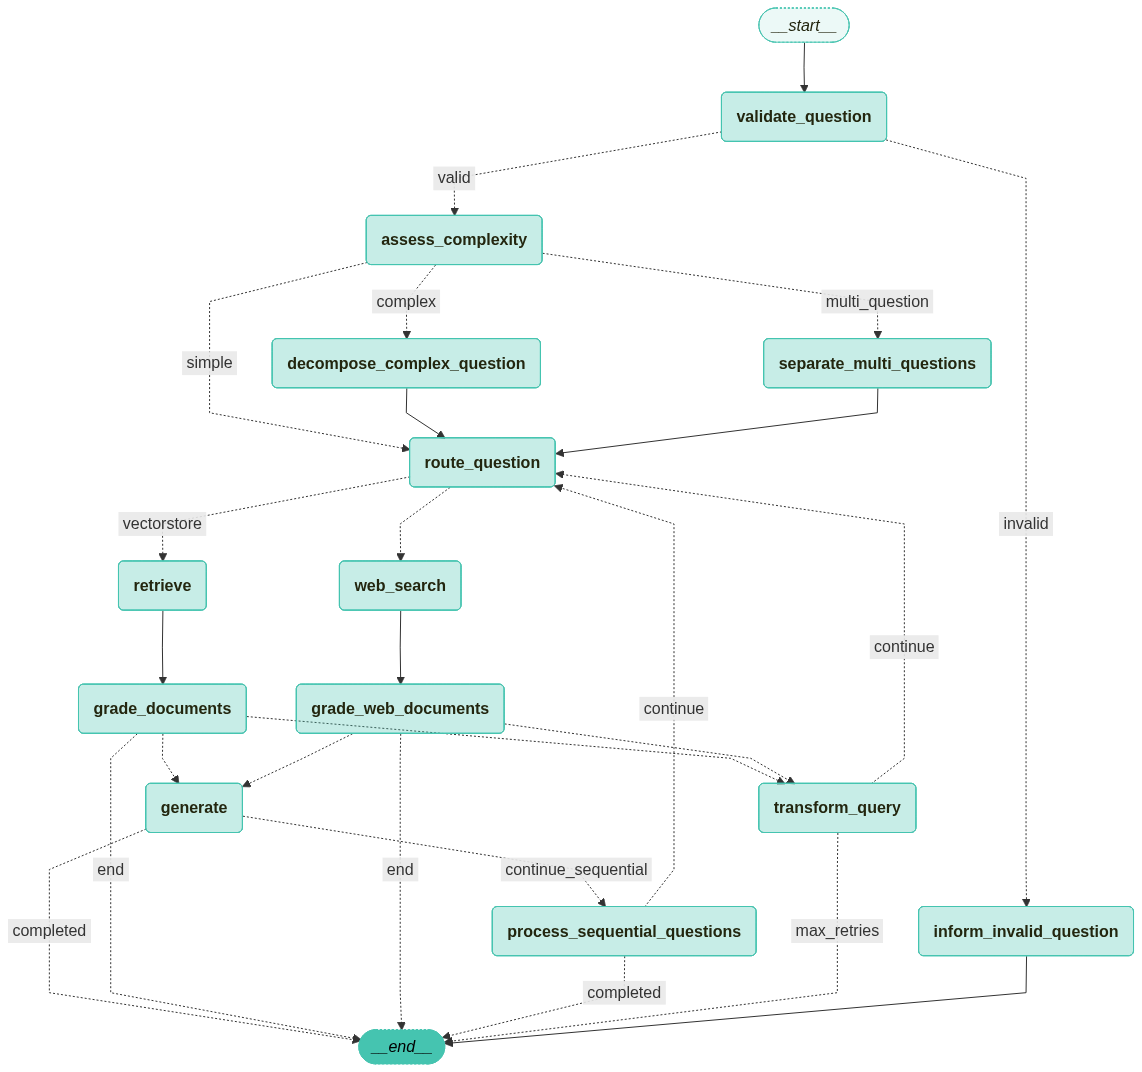

In [28]:
from langchain_teddynote.graphs import visualize_graph

visualize_graph(app)

In [29]:
# 최종 사용자 입력 및 답변 출력 시스템
print("🌱 농작업 도우미 - 최종 실행")
print("=" * 80)

# 1단계: 경작지 위치 설정 (사용자 입력)
print("📍 1단계: 경작지 위치 설정")
print("-" * 50)

# 경작지 위치 설정
farm_location = setup_farm_location()

if not farm_location:
    print("❌ 경작지 위치 설정이 취소되었습니다.")
    print("프로그램을 종료합니다.")
else:
    print(f"✅ 경작지 위치 설정 완료: {farm_location['road_address']}")
    print("=" * 80)
    
    # 2단계: 사용자 질문 입력
    print("🤖 2단계: 농작업 질문 입력")
    print("-" * 50)
    print("💡 농작업과 관련된 질문을 입력해주세요.")
    
    # 사용자 질문 입력
    user_question = input("질문을 입력하세요: ").strip()
    
    if not user_question:
        print("❌ 질문이 입력되지 않았습니다.")
    else:
        print(f"\n🔍 입력된 질문: {user_question}")
        print("=" * 80)
        
        # 3단계: LangGraph 실행
        print("🤖 3단계: LangGraph 질문 처리 중...")
        print("-" * 50)
        
        # config 설정(재귀 최대 횟수, thread_id)
        config = RunnableConfig(recursion_limit=20, configurable={"thread_id": random_uuid()})

        # 질문 입력
        inputs = {
            "question": user_question,
            "retry_count": 0,
            "strategy": "initial",
            "source_type": "unknown"
        }

        # 그래프 실행
        result = app.invoke(inputs, config)

        print("=" * 80)
        print("📋 질문:", inputs["question"])
        print("=" * 80)
        
        # 4단계: 답변 포맷팅 및 출력
        print("💬 답변:")
        print("-" * 50)
        
        # 답변에 마크다운 형식과 학명 보호 기능이 있는 줄바꿈 적용
        answer = result.get("generation")
        if answer:
            import re
            
            # 1단계: 학명/약어 보호 (줄바꿈 방지)
            scientific_names = re.findall(r'\b[A-Z]\.\s*[a-z]+', answer)
            protected_text = answer
            replacements = {}
            
            # 학명 보호
            for i, name in enumerate(scientific_names):
                placeholder = f"__SCIENTIFIC_NAME_{i}__"
                protected_text = protected_text.replace(name, placeholder)
                replacements[placeholder] = name
            
            # 2단계: 마크다운 헤더와 소스 부분에 줄바꿈 추가
            # ## 헤더 앞에 줄바꿈 추가
            protected_text = re.sub(r'([.!?])\s*(##)', r'\1\n\n\2', protected_text)
            
            # **Source** 앞에 줄바꿈 추가
            protected_text = re.sub(r'([.!?])\s*(\*\*Source\*\*)', r'\1\n\n\2', protected_text)
            
            # 3단계: 문장 단위로 줄바꿈
            sentences = re.split(r'[.!?]\s+', protected_text)
            
            formatted_sentences = []
            for sentence in sentences:
                sentence = sentence.strip()
                if sentence:
                    # 마크다운 헤더나 소스는 그대로 유지
                    if sentence.startswith('##') or sentence.startswith('**Source**'):
                        formatted_sentences.append(sentence)
                    # 긴 문장은 단어 단위로 줄바꿈
                    elif len(sentence) > 80:
                        words = sentence.split()
                        lines = []
                        current_line = ""
                        
                        for word in words:
                            test_line = current_line + (" " if current_line else "") + word
                            if len(test_line) <= 80:
                                current_line = test_line
                            else:
                                if current_line:
                                    lines.append(current_line)
                                    current_line = word
                                else:
                                    lines.append(word)
                                    current_line = ""
                        
                        if current_line:
                            lines.append(current_line)
                        
                        formatted_sentences.append("\n".join(lines))
                    else:
                        formatted_sentences.append(sentence)
            
            # 4단계: 보호된 학명/약어 복원
            final_text = "\n\n".join(formatted_sentences)
            for placeholder, original in replacements.items():
                final_text = final_text.replace(placeholder, original)
            
            print(final_text)
        else:
            print("답변: 답변을 생성할 수 없습니다.")
        
        print("=" * 80)
        
        # 5단계: 경작지 정보 및 처리 결과 요약
        print("📍 설정된 경작지 정보:")
        print(f"   주소: {farm_location['road_address']}")
        print(f"   좌표: {farm_location['longitude']}, {farm_location['latitude']}")
        print(f"   법정동: {farm_location['legal_address']}")
        print("-" * 50)
        
        # 처리 결과 요약
        print("📊 처리 결과 요약:")
        print(f"   질문 개수: {result.get('question_count', 1)}")
        print(f"   질문 인덱스: {result.get('question_index', 0)}")
        if result.get('primary_question'):
            print(f"   첫 번째 질문: {result.get('primary_question')}")
        if result.get('secondary_question'):
            print(f"   두 번째 질문: {result.get('secondary_question')}")
        
        print("=" * 80)
        print("🎉 농작업 도우미 실행 완료!")
        print("=" * 80)
        
        # 디버그 정보 (DEBUG_MODE가 True일 때만 출력)
        debug_print("=== FINAL RESULT ===")
        debug_print(f"Generation: {result.get('generation')}")
        debug_print(f"Question count: {result.get('question_count')}")
        debug_print(f"Question index: {result.get('question_index')}")
        debug_print(f"Primary question: {result.get('primary_question')}")
        debug_print(f"Secondary question: {result.get('secondary_question')}")


🌱 농작업 도우미 - 최종 실행
📍 1단계: 경작지 위치 설정
--------------------------------------------------
🌱 경작지 위치 설정

📍 경작지 주소를 입력해주세요:
예시: 서울시 강남구 테헤란로 123, 전라남도 순천시 중앙로 255
      또는: 순천대학교, 서울시청, 강남역 등

🔍 입력된 주소: 전남 순천시 중앙로 255
📍 주소를 좌표로 변환하고 정확한 주소를 확인하는 중...

✅ 주소 변환 완료!
📋 확인된 정보:
   입력 주소: 전남 순천시 중앙로 255
   좌표: 127.4809015, 34.9689183
   도로명 주소: 전라남도 순천시 중앙로 255
   법정동 주소: 전라남도 순천시 석현동

🎉 경작지 위치 설정 완료!
📍 설정된 위치: 전라남도 순천시 중앙로 255
📍 좌표: 127.4809015, 34.9689183
✅ 경작지 위치 설정 완료: 전라남도 순천시 중앙로 255
🤖 2단계: 농작업 질문 입력
--------------------------------------------------
💡 농작업과 관련된 질문을 입력해주세요.

🔍 입력된 질문: 딸기 흰가루병 방제에 쓰이는 대표적인 농약과 사용법을 알려주세요
🤖 3단계: LangGraph 질문 처리 중...
--------------------------------------------------
📋 질문: 딸기 흰가루병 방제에 쓰이는 대표적인 농약과 사용법을 알려주세요
💬 답변:
--------------------------------------------------
딸기 흰가루병 방제에 쓰이는 대표적인 농약은 가루싹(액상), 더마니(수용), 미리본(액상), 블랙다이아(과훈), 비반도(액상),
옵션(액상)입니다

사용법은 1000~2000배로 희석하여 피해 잎 뒷면까지 충분히 분무하며, 병 발생 초기와 온도 상승기(봄철)에 7~10일 간격으로 2~3회
사용하고, 수확 3일 전까지 적용해야 합니다

**Source**
- d